In [3]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet, TubularReactor
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize, least_squares
from scipy.ndimage import convolve1d

import logging
from scipy import interpolate
from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
df = process_roi_txt_to_excel("Phas_6_M10_Internode_below_leaf.txt", "Phas_6_M10_Internode_below_leaf.xlsx")

In [5]:
xi=list(df.columns)
t=df.index.to_numpy()

data_cor=df[xi].to_numpy(dtype=float)

data_unc=df[xi].to_numpy(dtype=float)*np.exp(-0.000567*60*t.reshape(len(t),1))

steps=len(data_cor)

d_xi=[]

for i in range(1,len(xi)):
     d_xi.append(float(xi[i])-float(xi[i-1]))

xi=list(np.array(xi)[[3,4,6,7,8,9,10,11]])


exp_data = data_cor*np.exp(-0.000567*60*t.reshape(len(t),1))



weights = 1 #/ np.mean(exp_data, axis=0)




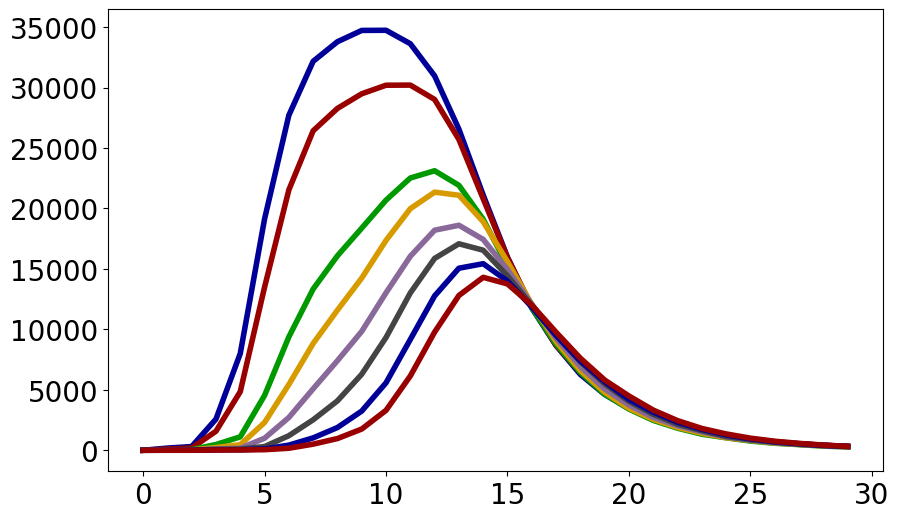

In [6]:

normalized_data = (data_cor[:,[3,4,6,7,8,9,10,11]].T  - data_cor[:,[3,4,6,7,8,9,10,11]].T .min(axis=1, keepdims=True)).T

monotonic_data = normalized_data.copy().T

# Force monotonicity in the first 3 points of each row
for i in range(monotonic_data.shape[0]):
    # Set monotonicity to match the trend from the 4th point
    baseline = monotonic_data[i, 3]*0.1
    monotonic_data[i, :3] = np.linspace(monotonic_data[i, 0], baseline, 3)

plt.plot(monotonic_data.T/np.exp(0.000567*60*t.reshape(len(t),1)))

smooth_exp_data = monotonic_data.T/np.exp(0.000567*60*t.reshape(len(t),1))

exp_data = smooth_exp_data
exp_data = exp_data / np.max(exp_data)

num_new_rows = 2
num_columns = exp_data.shape[1]

new_rows = np.zeros((num_new_rows, num_columns))


exp_data = np.vstack((new_rows, exp_data))
t = np.hstack((t,[150.,155.]))

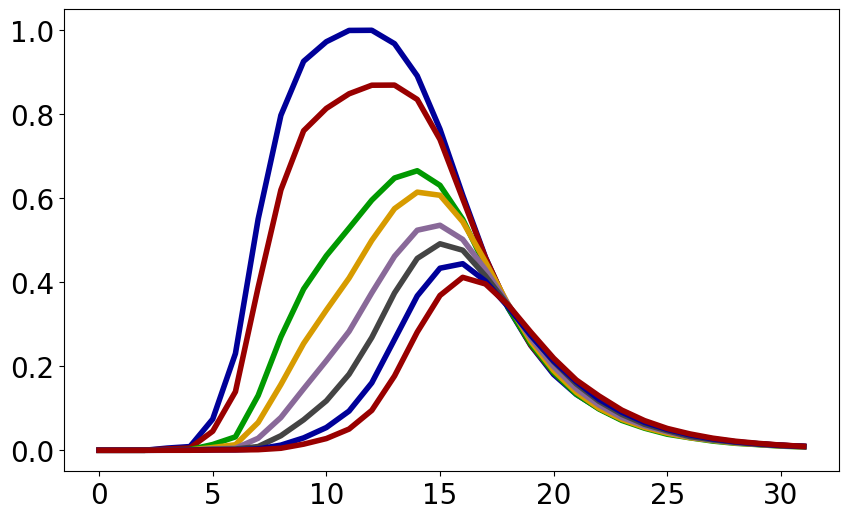

In [7]:
plt.plot(exp_data)

In [8]:
def exponential_kernel(size=200, scale=20.0):
    """
    Continuous exponential kernel for smoothing.

    Parameters:
        size (int): Number of kernel points (support size).
        scale (float): Controls the exponential decay length (continuous).

    Returns:
        np.ndarray: Normalized exponential kernel.
    """
    size = int(size)
    x = np.linspace(-size / 2, size / 2, size)
    kernel = np.exp(-np.abs(x) / scale)
    return kernel / kernel.sum()


# Updated Three-Point Model with Initial Constant Velocity (Using t1, t2, t3)
def velocity_profile(t, p_v0, p_t1, p_t2, p_t3, p_v2, p_v3, smoothing_width=100):
    """
    Generates a velocity profile with an initial constant velocity before change at t1.
    
    Parameters:
        t (numpy.ndarray): Time points to evaluate the velocity profile.
        p_v0 (float): Initial constant velocity.
        p_t1 (float): Duration for which velocity remains constant at p_v0.
        p_t2 (float): Time interval for velocity change.
        p_t3 (float): Time interval for recovery.
        p_v2 (float): Velocity at t2 (after change).
        p_v3 (float): Velocity at t3 (after recovery).
        smoothing_width (int): Width of the exponential kernel for smoothing.
    
    Returns:
        numpy.ndarray: Smoothed velocity profile.
    """
    time_points = [0, p_t1, p_t2, p_t3]  # Ensure an initial constant phase
    velocities = [p_v0, p_v0, p_v2, p_v3]  # Hold velocity constant before change

    profile = np.interp(t, time_points, velocities)

    kernel = exponential_kernel(smoothing_width, scale=smoothing_width)
    smoothed_profile = convolve1d(profile, kernel, mode="nearest")

    return smoothed_profile



In [9]:
def setup_process(x):
    
    p_volumetric_flow_rate_const_t0 = x[0]
    p_mct1_e12 = x[1]
    p_total_porosity = x[2]
    p_col_dispersion = x[3]
    p_x0 = x[4]
    p_dt1= x[5]
    p_dt2= x[6]
    p_dt3= x[7]
    p_v2= x[8] 
    p_v3= x[9]
    p_t0 =x[10]
    p_s=x[11]
    p_mct_disp=x[12]

        
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    tube = TubularReactor(component_system, name='stem')
    mct1 = MCT(component_system, nchannel=2, name='mct1')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 30


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(tube)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(outlet)
    
    tube.length = p_x0
    tube.axial_dispersion = 0
    tube.diameter = np.sqrt(1/np.pi)

    leaf.total_porosity = p_total_porosity
    leaf.length = 0.01
    leaf.diameter = np.sqrt(1/np.pi)*15
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, tube)
    mct_flow_sheet.add_connection(tube, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, outlet, origin_port = 'channel_0')
 
    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[-1]/1000
    
    mct1.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct_disp
    
    mct1.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12]],
                                    [[0.0], [0.0]],
                                    ])
                                


    process.cycle_time = 60*t[-1]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [1],0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [1],p_t0*60+0.1)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0],p_t0*60+6*60)
    
    t_curve = np.linspace(0, t[-1] * 60, len(t)*5)
  
    
    p_t1 = p_dt1
    p_t2 = p_dt2
    p_t3 = p_dt3
    
  
    curve_modified =velocity_profile(t_curve, p_v0=p_volumetric_flow_rate_const_t0, p_t1=p_t1 * 60, p_t2=p_t2 * 60, p_t3=p_t3 * 60, 
                                    p_v2=p_v2, p_v3=p_v3, smoothing_width=p_s)

    process.add_flow_rate_profile(inlet, t_curve, curve_modified)
    
    #plt.plot(t_curve, curve_modified, label="Smoothed Profile")
    #_ = process.plot_events()    

        
    return process

In [10]:
xi[2]/1000-xi[0]/1000+xi[-1]/1000-xi[2]/1000

np.float64(0.08995423004191223)

In [11]:
# Define min and max values for each parameter
param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),  # log-scaling, volumetric_flow_rate_const
    'mct1_e12': (1.53039589e-5, 6.12158354e-03),  # log-scaling, mct1_e12
    'total_porosity': (0.1, 0.99),          # linear scaling, total_porosity
    'col_dispersion': (2.83319089e-12, 1.13327635e-04),  # log-scaling, col_dispersion
    'x0': (0.001, 0.05),           # linear scaling, t0
    'p_t1' : (0,25),
    'p_t2' : (25,60),
    'p_t3' : (60,120),
    'p_v2' : (1e-05, 8e-05),
    'p_v3' : (1e-05, 2e-04),
    'p_t0': (0,10),
    'p_s': (1,50),
    'mct_dispersion': (2.83319089e-10, 1.13327635e-04)}


    
def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

In [12]:
def mct_obj(x_norm):

    x = x_norm #denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:])-lenghts[0])

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    
    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    print(np.array(x_norm), SSQ)
    
    plot_fit(time_new, calc_data, exp_data)

    return SSQ

In [13]:
def mct_obj_norm(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    print(np.array(x_norm), SSQ)
    
    plot_fit(time_new, calc_data, exp_data)

    return SSQ

In [14]:
def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)

    process = setup_process(x)

    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()


    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    plot_fit(time_new, calc_data, exp_data)

    return weighted_residuals

In [15]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(32,8),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time/60,calc_data[:], label="mct1", color='k', linewidth=1)
    ax1.plot(time/60,res, label="res", color='b')
    ax1.plot(time/60,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)

In [16]:
simulator = Cadet()    
simulator.time_resolution = 60
simulator.use_dll = True

In [40]:
analyze_parameters([0.5035913 , 0.38647886, 0.30182913, 0.38142811, 0.83253395,
       0.68662842, 0.64442489, 0.31791975, 0.37606794, 0.42837126,
       0.38306982, 0.04321471, 0.29647109])

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.05682347e-04      0.50      
mct1_e12                      1.55040432e-04      0.39      
total_porosity                3.68627926e-01      0.30      
col_dispersion                2.24861555e-09      0.38      
x0                            4.17941635e-02      0.83      
p_t1                          1.71657105e+01      0.69      
p_t2                          4.75548711e+01      0.64      
p_t3                          7.90751850e+01      0.32      
p_v2                          3.63247558e-05      0.38      
p_v3                          9.13905394e-05      0.43      
p_t0                          3.83069820e+00      0.38      
p_s                           3.11752079e+00      0.04      
mct_dispersion                1.29755169e-08      0.30      


In [18]:
denormalize_parameters([0.60573086, 0.41178878, 0.59060347, 0.37602127, 0.05263158,
       0.26831251, 0.7265289 , 0.29778507, 0.38978046, 0.46026042])

IndexError: list index out of range

In [ ]:
normalize_parameters([1.25088863e-04, 1.80427570e-04, 6.25637088e-01, 2.04555937e-09,
       0.01, 5.36625020e+00, 4.90611560e+01, 7.78671042e+01,
       3.72846322e-05, 9.74494798e-05])

IndexError: list index out of range

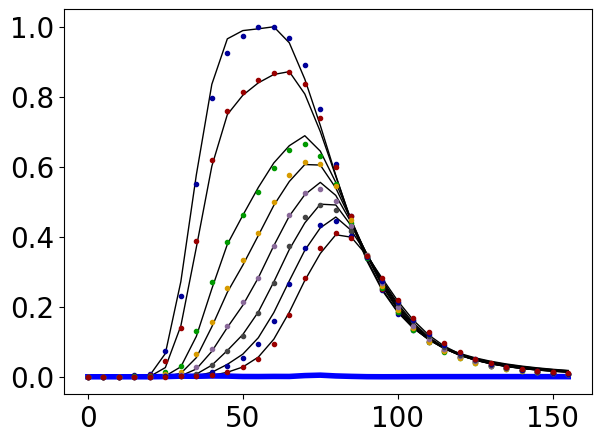

np.float64(0.05676750869757072)

In [ ]:
mct_obj_norm([0.5035913 , 0.38647886, 0.30182913, 0.38142811, 0.83253395,
       0.68662842, 0.64442489, 0.31791975, 0.37606794, 0.42837126,
       0.38306982, 0.04321471, 0.29647109])


# [0.73197943, 0.40815342, 0.59664658, 0.37314854, 0.47605069,
#        0.28305801, 0.51770392, 0.26671368, 0.34650416, 0.45277878]


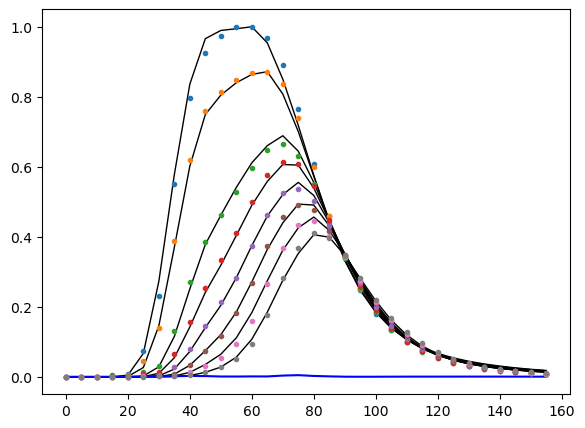

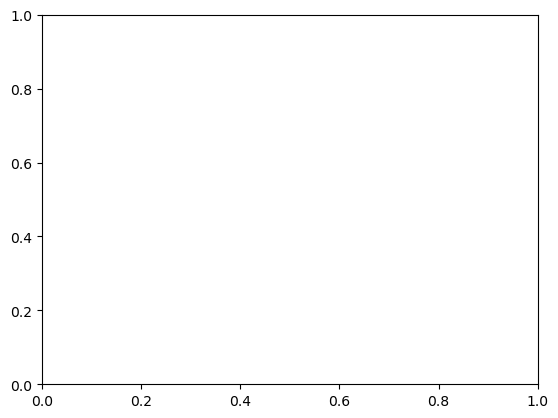

In [30]:
x0 = np.array([0.5035913 , 0.38647886, 0.30182913, 0.38142811, 0.83253395,
       0.68662842, 0.64442489, 0.31791975, 0.37606794, 0.42837126,
       0.38306982, 0.04321471, 0.29647109])

# Initialize the plot
fig, ax = plt.subplots()

weights = 1 / np.max(exp_data, axis=0)

fig.canvas.draw()
display.display(fig)

result_nm= minimize(
    fun=mct_obj_norm,
    x0=x0,
    method='L-BFGS-B',
    jac = '3-point',
     bounds= (13*((0,1),)),
       options = {
       'disp': True,
       'maxfun': 2000
       })

In [31]:
result_nm.x

array([0.50098305, 0.38652678, 0.30049031, 0.38200012, 0.83272355,
       0.68790554, 0.64475988, 0.31811806, 0.37627048, 0.42871036,
       0.38357051, 0.04331518, 0.29663782])

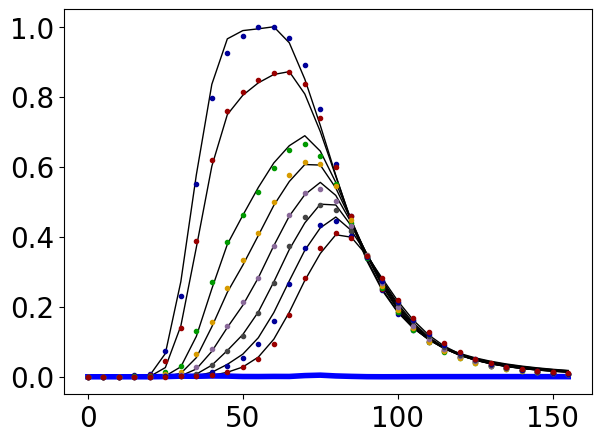

Optimization terminated successfully.
         Current function value: 0.056768
         Iterations: 873
         Function evaluations: 1553


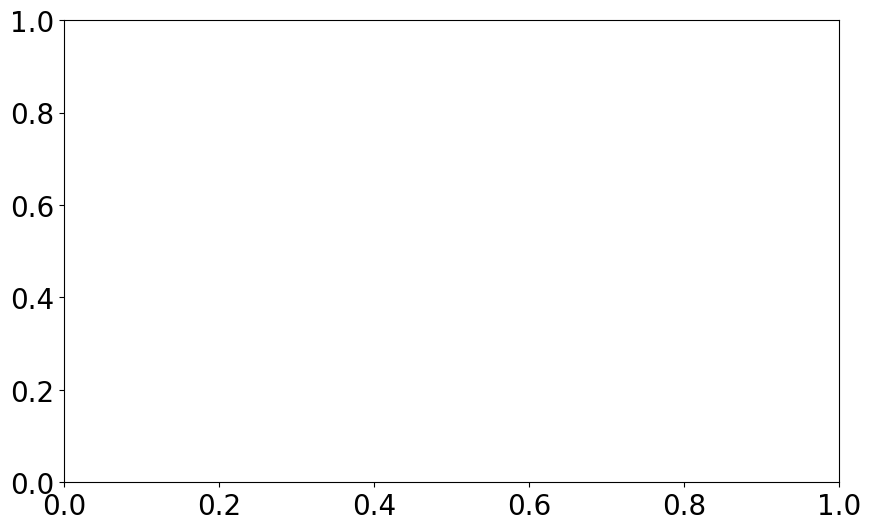

In [ ]:
x0 = np.array([0.50509157, 0.3868907 , 0.30352836, 0.38164884, 0.95976149,
       0.67531607, 0.64494915, 0.32071493, 0.37143201, 0.43227845,
       0.30221536, 0.04227425, 0.33567587])

# Initialize the plot
fig, ax = plt.subplots()

weights = 1 / np.max(exp_data, axis=0)

fig.canvas.draw()
display.display(fig)

result_nm= minimize(
    fun=mct_obj_norm,
    x0=x0,
    method='Nelder-Mead',
     bounds= (13*((0,1),)),
       options = {
       'disp': True,
       'maxiter': 2000,
       'adaptive':True
       })

In [ ]:
result_nm.x

array([0.5035913 , 0.38647886, 0.30182913, 0.38142811, 0.83253395,
       0.68662842, 0.64442489, 0.31791975, 0.37606794, 0.42837126,
       0.38306982, 0.04321471, 0.29647109])

In [19]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct1 = process.flow_sheet.units[3]

    lenghts = [x / 1000 for x in xi]

    eval_location1 = list(np.array(lenghts[:]))

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
   

    calc_data = calc_data_mct1 # np.hstack((calc_data_mct1,calc_data_mct2))
    calc_data = calc_data/np.max(calc_data)
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14) 
    
    t_plot = [ -10, -5, 0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145.]
    
    time_new_plot = np.arange(-10,145+1,1)


    plt.plot(time_new_plot[10:],calc_data[10:], label="Simulated Data", linewidth=1.5)
    plt.gca().set_prop_cycle(None)
    plt.plot(t_plot[2:],exp_data[2:], '.',  markersize=8,label="Experimental Data",)
    
    plt.xlabel("Time [min]")
    plt.ylabel("Activity [a.u.]")
    
    
    # Remove duplicate labels while keeping the first occurrence
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_labels = {}
    unique_handles = []

    for handle, label in zip(handles, labels):
        if label not in unique_labels:  # Keep first occurrence
            unique_labels[label] = handle
            unique_handles.append(handle)

    # Add legend with unique labels
    plt.legend(unique_handles, unique_labels.keys(), fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=20)
    plt.ylabel("Activity [a.u.]", fontsize=20)

C:\Users\h.lanzrath\CADET\CADET-Python\cadet\cadet.py:510: FutureWarning: Cadet.run_load() will be removed in a future release. Please use Cadet.run_simulation()
  warnings.warn(


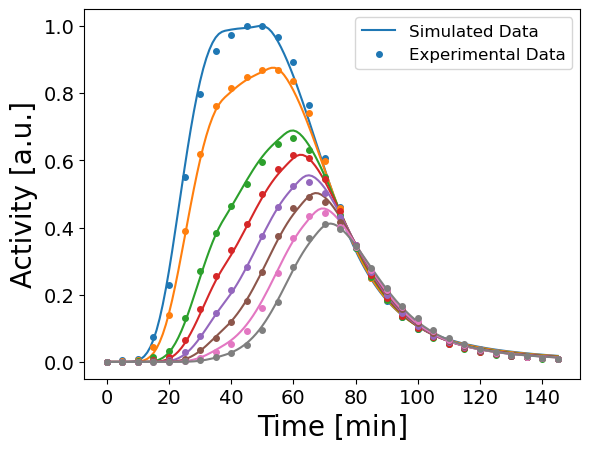

In [39]:
plot_pretty([0.5035913 , 0.38647886, 0.30182913, 0.38142811, 0.83253395,
       0.68662842, 0.64442489, 0.31791975, 0.37606794, 0.42837126,
       0.38306982, 0.04321471, 0.29647109])

In [ ]:
Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    1.05186780e-04      0.50      
mct1_e12                      1.55084952e-04      0.39      
total_porosity                3.67436376e-01      0.30      
col_dispersion                2.27124333e-09      0.38      
x0                            4.18034539e-02      0.83      
p_t1                          1.71976385e+01      0.69      
p_t2                          4.75665958e+01      0.64      
p_t3                          7.90870836e+01      0.32      
p_v2                          3.63389336e-05      0.38      
p_v3                          9.14549684e-05      0.43      
p_t0                          3.83570510e+00      0.38      
p_s                           3.12244382e+00      0.04      
mct_dispersion                1.30034532e-08      0.30   

SyntaxError: invalid syntax (93557601.py, line 1)

In [22]:
Parameter 0: ±12.667518444933885%
Parameter 1: ±1.9020030450957373%
Parameter 2: ±4.595847726985865%
Parameter 3: ±1.8388469330787722%
Parameter 4: ±44.914687529072786%
Parameter 5: ±43.11176737676474%
Parameter 6: ±2.92399562177335%
Parameter 7: ±10.782578893643011%
Parameter 8: ±5.054362702071136%
Parameter 9: ±4.538610679823591%
Parameter 10: ±8181514.765619075%
Parameter 11: ±7558.110391788354%
Parameter 12: ±25.39374467918571%

SyntaxError: invalid character '±' (U+00B1) (2731592055.py, line 1)

In [24]:
t

array([  0.,   5.,  10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,
        55.,  60.,  65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105.,
       110., 115., 120., 125., 130., 135., 140., 145., 150., 155.])

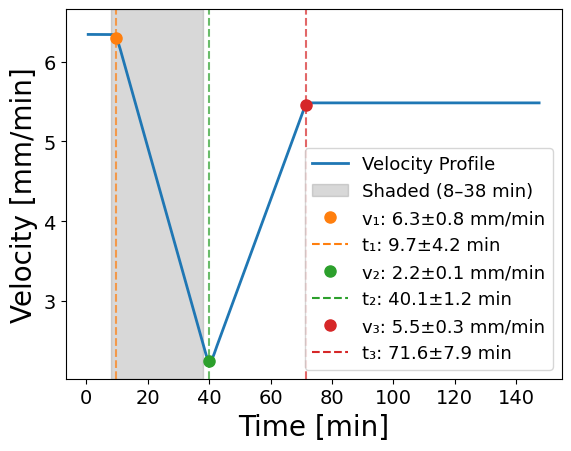

In [38]:

# Example parameters (Replace these with actual values)
p_v0 = 1.05682347e-04 
p_t1 =   1.71657105e+01 
p_t2 =    4.75548711e+01  
p_t3 =  7.90751850e+01   
p_v2 =   3.63247558e-05 
p_v3 = 9.13905394e-05   


# Define time array and parameters
t_plot = np.linspace(0, 155 * 60, len(t)*60)  # Ensure `t` is defined

final_process = setup_process(denormalize_parameters([0.5035913 , 0.38647886, 0.30182913, 0.38142811, 0.83253395,
       0.68662842, 0.64442489, 0.31791975, 0.37606794, 0.42837126,
       0.38306982, 0.04321471, 0.29647109]))
smoothed_interpolated = final_process.parameter_timelines['flow_sheet.inlet.flow_rate'].value(t_plot) * (1/1.66667e-5)

plt.style.use('default')

key_times_min =[p_t1-10+2.5, p_t2-10+2.5, p_t3-10+2.5]
velocities = np.array([p_v0, p_v2, p_v3]) * (1/1.66667e-5)
uncertainties_time=[0.43, 0.03, 0.11]
uncertainties_velocity=[0.12,0.05,0.05]

import matplotlib.lines as mlines

# Plot velocity profile
t_plot = np.linspace(-10+2.5, 145+2.5, len(t)*60)
plt.plot(t_plot[100:], smoothed_interpolated[100:], label="Velocity Profile", linewidth=2)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Y-axis padding for annotations
plt.ylim(top=np.max(smoothed_interpolated) * 1.05)
plt.ylim(bottom=np.min(smoothed_interpolated) * 0.9)

# Add shaded shadow period
plt.axvspan(8, 38, color='gray', alpha=0.3, label="Shaded (8–38 min)")

# Store custom legend handles
custom_handles = []

def to_subscript(number):
    subscript_digits = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
    return str(number).translate(subscript_digits)


# Mark key transition points
for idx, key_time in enumerate(key_times_min):
    color = plt.rcParams['axes.prop_cycle'].by_key()['color'][idx+1]

    # Values
    nearest_index = np.abs(t_plot - key_time).argmin()
    y_value = smoothed_interpolated[nearest_index]
    velocity = velocities[idx]
    velocity_unc = velocity * uncertainties_velocity[idx]
    time_unc = key_time * uncertainties_time[idx]

    # Draw vertical line
    plt.axvline(x=key_time, linestyle='--', color=color, alpha=0.7)

    # Draw dot
    plt.plot(key_time, y_value, 'o', color=color, markersize=8)
    
    sub = to_subscript(idx + 1)
    
    
    velocity_label = f'v{sub}: {velocity:.1f}±{velocity_unc:.1f} mm/min'
    dot_handle = mlines.Line2D([], [], color=color, marker='o', linestyle='None', markersize=8, label=velocity_label)
    custom_handles.append(dot_handle)

    time_label = f't{sub}: {key_time:.1f}±{time_unc:.1f} min'
    line_handle = mlines.Line2D([], [], linestyle='--', color=color, label=time_label)
    custom_handles.append(line_handle)
# Labels and final legend
plt.xlabel("Time [min]", fontsize=20)
plt.ylabel("Velocity [mm/min]", fontsize=20)

# Include default entries (velocity profile & shadow period) + custom handles
default_handles, default_labels = plt.gca().get_legend_handles_labels()
plt.legend(default_handles + custom_handles, default_labels + [h.get_label() for h in custom_handles], fontsize=13, loc='lower right')

plt.show()

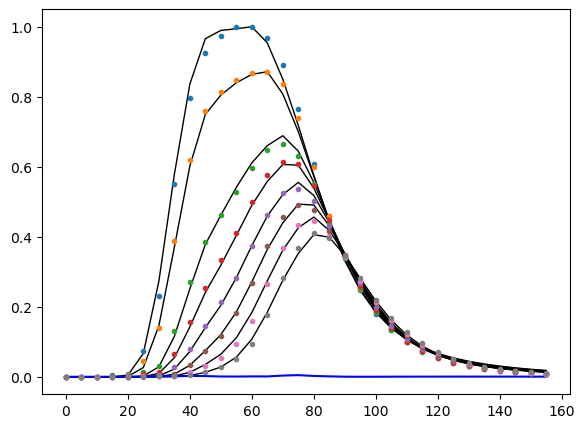

Parameter 0: ±31.784037182990264%
Parameter 1: ±1.704199466882947%
Parameter 2: ±17.49029284257531%
Parameter 3: ±4.81131463516863%
Parameter 4: ±51.545457404733405%
Parameter 5: ±82.93920369750818%
Parameter 6: ±2.9160538941499508%
Parameter 7: ±10.416856223069722%
Parameter 8: ±5.177161069893456%
Parameter 9: ±4.121165484556621%
Parameter 10: ±3303429.3367650267%
Parameter 11: ±7909.392624645539%
Parameter 12: ±25.596735655586095%


In [34]:
x_best_fit = [0.50098305, 0.38652678, 0.30049031, 0.38200012, 0.83272355,
       0.68790554, 0.64475988, 0.31811806, 0.37627048, 0.42871036,
       0.38357051, 0.04331518, 0.29663782]

def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.inv(J.T @ J)  # (J^T J)^-1
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")